In [24]:
import pandas as pd
import numpy as np

In [ ]:
# merged = merged.drop(columns=["Unnamed:0"])
merged

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,328962.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,85157.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,39427.386,-0.390397,-3.492136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,1792.3250,24.40,1.0,128939.0,4034870.0,1438.0,0.010601,13.390429,501.920132,504.474684,103970.897,-5.046648,-0.016089
149,2024,전북특별자치도,1741.6360,23.51,1.0,119854.0,3736595.0,1839.0,0.011483,10.794448,469.189314,537.972610,66792.381,-5.533847,-0.308514
150,2024,제주특별자치도,669.0510,34.01,1.0,12905.0,3501134.0,1053.0,0.005979,18.832645,494.285189,202.652238,26928.491,-5.538364,-0.833774
151,2024,충청남도,2126.6115,32.35,1.0,314597.0,4680157.0,1832.0,0.011286,9.357610,527.287189,545.099532,150681.268,-2.439551,0.305802


In [ ]:
# 결측치 확인
merged[merged.isna().any(axis=1)]

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)


In [ ]:
# 공선성 줄이기 (일부 지표 상관계수 높음)
# 1) 규모 제거 - 1인당 GRDP: 지역내총생산(십억원) -> 원 단위로 바꾸고 / 인구(명)
#     십억원(=1e9) 이므로 * 1e9
merged["지역내총생산(1인당_원)"] = (merged["지역내총생산(십억원)"] * 1e9) / (merged["연앙인구수(천명)"] * 1000)

# 2) 규모 제거 - 제조업 종사자 "천명당" (이미 천명당 컬럼이면 이 단계 생략)
merged["제조업종사자수(천명당)"] = merged["제조업종사자수"] / merged["연앙인구수(천명)"]

# 3) 절대규모 변수 제거(권장)
merged = merged.drop(columns=["지역내총생산(십억원)", "제조업종사자수"])

In [ ]:
# merged.to_csv('data/busan_youth_v4.csv')

In [ ]:
# 지역내총생산 컬럼 앞으로
front = ["연도", "행정구역", "지역내총생산(1인당_원)"]
others = [c for c in merged.columns if c not in front]
merged = merged[front + others]

In [ ]:
# 증감률 컬럼 뒤로
tail = ["청년_19_29_증감률(%)", "청년_30_39_증감률(%)"]
cols = [c for c in merged.columns if c not in tail]
merged = merged[cols + tail]

In [ ]:
merged

,연도,행정구역,지역내총생산(1인당_원),연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,제조업종사자수(천명당),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,2.908167e+07,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,37.340320,1.149646,-2.070627
1,2016,경기도,3.464923e+07,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,102.011006,1.820153,-0.773010
2,2016,경상남도,3.389758e+07,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,129.466977,-0.054546,-2.108272
3,2016,경상북도,4.181742e+07,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,122.587948,-0.105801,-2.177146
4,2016,광주광역시,2.697677e+07,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,58.265613,-0.390397,-3.492136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,5.800895e+07,1792.3250,24.40,1.0,4034870.0,1438.0,0.010601,13.390429,501.920132,504.474684,71.939520,-5.046648,-0.016089
149,2024,전북특별자치도,3.835037e+07,1741.6360,23.51,1.0,3736595.0,1839.0,0.011483,10.794448,469.189314,537.972610,68.816905,-5.533847,-0.308514
150,2024,제주특별자치도,4.024879e+07,669.0510,34.01,1.0,3501134.0,1053.0,0.005979,18.832645,494.285189,202.652238,19.288515,-5.538364,-0.833774
151,2024,충청남도,7.085510e+07,2126.6115,32.35,1.0,4680157.0,1832.0,0.011286,9.357610,527.287189,545.099532,147.933461,-2.439551,0.305802


In [ ]:
# merged = pd.read_csv('C:\project\\busan-ai-agent\\analysis\\notebooks\\data\\busan_youth_v3.csv').drop(columns=["Unnamed: 0"])
# df = pd.read_csv('C:\project\\busan-ai-agent\\analysis\\notebooks\\data\\busan_youth_v4.csv'

,Unnamed: 0,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,청년_19_29_증감률(%),청년_30_39_증감률(%),지역내총생산(1인당_원),제조업종사자수(천명당)
0,0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,1.149646,-2.070627,2.908167e+07,37.340320
1,1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,1.820153,-0.773010,3.464923e+07,102.011006
2,2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,-0.054546,-2.108272,3.389758e+07,129.466977
3,3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,-0.105801,-2.177146,4.181742e+07,122.587948
4,4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,-0.390397,-3.492136,2.697677e+07,58.265613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,148,2024,전라남도,1792.3250,24.40,1.0,4034870.0,1438.0,0.010601,13.390429,501.920132,504.474684,-5.046648,-0.016089,5.800895e+07,71.939520
149,149,2024,전북특별자치도,1741.6360,23.51,1.0,3736595.0,1839.0,0.011483,10.794448,469.189314,537.972610,-5.533847,-0.308514,3.835037e+07,68.816905
150,150,2024,제주특별자치도,669.0510,34.01,1.0,3501134.0,1053.0,0.005979,18.832645,494.285189,202.652238,-5.538364,-0.833774,4.024879e+07,19.288515
151,151,2024,충청남도,2126.6115,32.35,1.0,4680157.0,1832.0,0.011286,9.357610,527.287189,545.099532,-2.439551,0.305802,7.085510e+07,147.933461


In [26]:
# 결측치 없음 확인
df[df.isna().any(axis=1)]  

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)


In [27]:
# 기술통계값
df.describe()

,연도,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
count,153.000000,153.000000,153.000000,153.000000,1.530000e+02,1.530000e+02,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,2020.000000,3013.769781,41.867647,0.555556,2.449641e+05,3.634695e+06,2115.169935,0.009311,7.551186,450.994706,664.223418,126852.359118,-1.374544,-1.703023
std,2.590468,3220.463176,15.375476,0.498536,2.962145e+05,4.476955e+05,3004.882494,0.003289,4.456561,53.225861,681.264288,146826.019840,3.311034,3.009730
min,2016.000000,225.992000,19.070000,0.000000,1.163400e+04,2.564480e+06,81.000000,0.003340,2.797471,345.802509,29.542562,10962.552000,-6.300299,-5.735596
25%,2018.000000,1457.271000,28.760000,0.000000,8.515700e+04,3.326347e+06,855.000000,0.006091,4.249024,413.490406,295.036689,51573.015000,-3.547263,-3.265744
50%,2020.000000,1854.771500,41.070000,1.000000,1.774270e+05,3.594988e+06,1284.000000,0.010282,6.244155,448.542842,497.475001,79762.196000,-1.487676,-2.216033
75%,2022.000000,2939.962000,52.350000,1.000000,2.779200e+05,3.905955e+06,1849.000000,0.011790,8.925185,478.318407,684.649468,116365.537000,0.034918,-0.892393
max,2024.000000,13598.221500,80.660000,1.000000,1.387627e+06,4.935566e+06,16741.000000,0.014854,20.799155,621.488161,3480.566202,651417.234000,20.691236,20.091652


In [28]:
# 상관 & 다중공선성 점검
num_cols = df.select_dtypes("number").columns
corr = df[num_cols].corr()
corr

,연도,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
연도,1.000000,-0.000509,-0.069478,0.866025,0.006842,0.578958,0.064802,-0.016809,0.110739,0.596602,0.116908,0.089127,-0.635532,0.022907
연앙인구수(천명),-0.000509,1.000000,0.556442,-0.000187,0.848775,0.290360,0.678491,-0.277266,-0.343934,0.227864,0.971425,0.969871,-0.017330,0.001834
재정자립도(%),-0.069478,0.556442,1.000000,-0.065624,0.294578,0.336754,0.593105,-0.434599,-0.632787,0.173227,0.473211,0.563416,0.154949,0.212005
통계방식변경,0.866025,-0.000187,-0.065624,1.000000,0.010093,0.465208,0.001992,-0.016898,0.099169,0.584640,0.133836,0.072307,-0.552196,-0.055758
제조업종사자수,0.006842,0.848775,0.294578,0.010093,1.000000,0.205703,0.240075,-0.294731,-0.305200,-0.019460,0.871901,0.776740,-0.026758,-0.003331
상용월평균급여(원),0.578958,0.290360,0.336754,0.465208,0.205703,1.000000,0.395514,0.003430,-0.302819,0.667151,0.304377,0.450007,-0.370341,0.041289
문화예술활동(건),0.064802,0.678491,0.593105,0.001992,0.240075,0.395514,1.000000,-0.103338,-0.248219,0.536289,0.592448,0.759567,-0.095279,0.009054
대학수(천명당),-0.016809,-0.277266,-0.434599,-0.016898,-0.294731,0.003430,-0.103338,1.000000,0.175232,0.142891,-0.287395,-0.217567,0.130029,0.050047
문화기반시설수(십만명당),0.110739,-0.343934,-0.632787,0.099169,-0.305200,-0.302819,-0.248219,0.175232,1.000000,0.066648,-0.309046,-0.304199,-0.015639,0.002752
전체산업종사자수(천명당),0.596602,0.227864,0.173227,0.584640,-0.019460,0.667151,0.536289,0.142891,0.066648,1.000000,0.231921,0.398441,-0.424874,-0.073100


In [52]:
# # 1) 컬럼명 바꾸기 (% 없애기)
# df = df.rename(columns={
#     "청년_19_29_증감률(%)": "청년_19_29_증감률(퍼센트)",
#     "청년_30_39_증감률(%)": "청년_30_39_증감률(퍼센트)",
#     "재정자립도(%)": "재정자립도(퍼센트)",
# })

In [30]:
df_cross= df.iloc[:,6:]
df_heat = df_cross.corr()

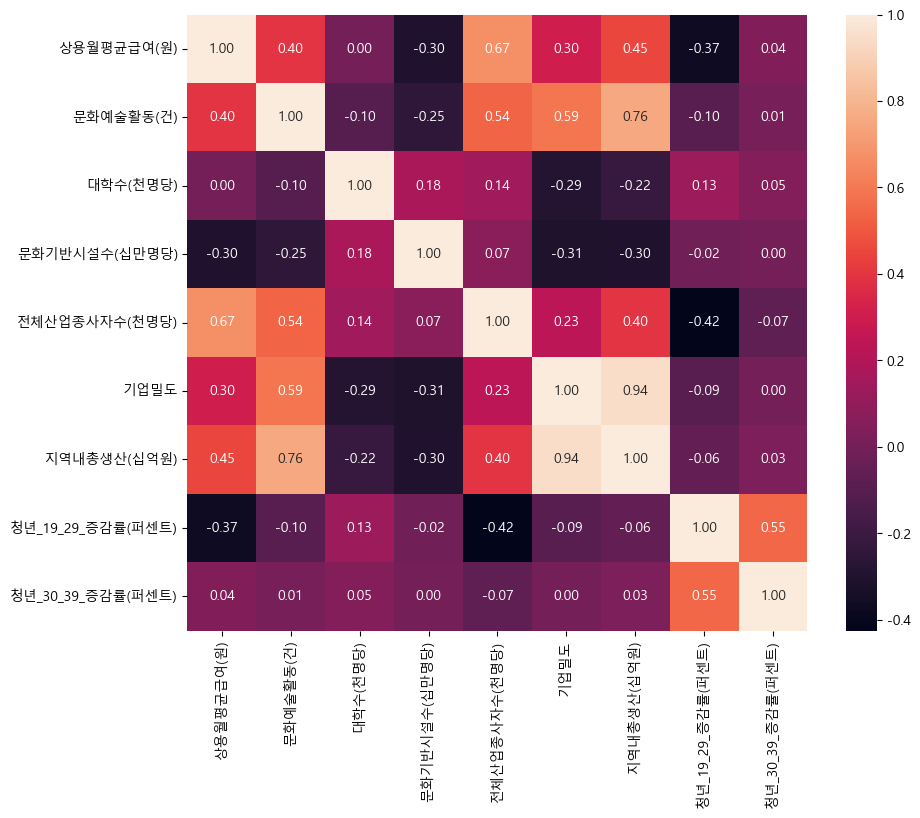

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".2f")
plt.show()


In [32]:
df.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(퍼센트)', '통계방식변경', '제조업종사자수',
       '상용월평균급여(원)', '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '전체산업종사자수(천명당)',
       '기업밀도', '지역내총생산(십억원)', '청년_19_29_증감률(퍼센트)', '청년_30_39_증감률(퍼센트)'],
      dtype='object')

In [ ]:
# keep = [
#     "상용월평균급여(원)",
#     "문화예술활동(건)",
#     "문화기반시설수(십만명당)",
#     "대학수(천명당)",
#     "재정자립도(퍼센트)"
# ]

# X2 = df[keep].replace([np.inf, -np.inf], np.nan).dropna()

# vif2 = pd.DataFrame({
#     "var": X2.columns,
#     "VIF": [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
# })

# print(vif2)


             var        VIF
0     상용월평균급여(원)  39.552007
1      문화예술활동(건)   2.146931
2  문화기반시설수(십만명당)   4.638577
3       대학수(천명당)  10.152500
4     재정자립도(퍼센트)  18.182851


# 통제변수 
- 지역내총생산
- 연앙인구수
- 재정자립도(%)

In [42]:
df_cross= df.iloc[:,5:]
df_heat = df_corr.corr()

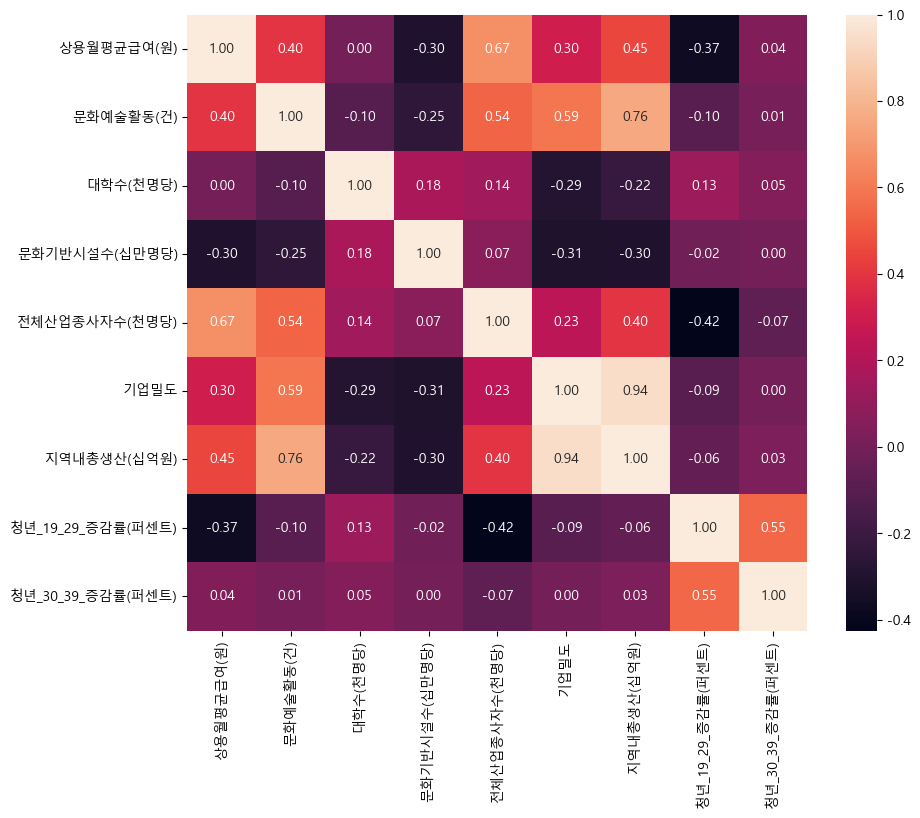

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".2f")
plt.show()

In [ ]:
# 공선성 줄이기 

# 1) 규모 제거(가공 지표 만들기) - 핵심 해결
# -----------------------------
# (1) 1인당 GRDP: 지역내총생산(십억원) -> 원 단위로 바꾸고 / 인구(명)
#     십억원(=1e9) 이므로 * 1e9
df["지역내총생산(1인당_원)"] = (df["지역내총생산(십억원)"] * 1e9) / (df["연앙인구수(천명)"] * 1000)

# (2) 제조업 종사자 "천명당" (이미 천명당 컬럼이면 이 단계 생략)
df["제조업종사자수(천명당)"] = df["제조업종사자수"] / df["연앙인구수(천명)"]

# (3) 기업밀도도 사실 규모와 강하게 엮이면, 대체로 "인구당 사업체"로도 한 번 만들어 비교 가능
#     (기업밀도 정의가 애매하면 이건 옵션으로만)
# df["사업체수(천명당)_대체"] = df["기업밀도"] / df["연앙인구수(명)"] * 1000  # 옵션(정의 확인 필요)

# -----------------------------
# 2) 공선성 줄이기: 절대규모 변수 제거(권장)
# -----------------------------
# 아래 3개(인구/GRDP/제조업 절대값)는 공선성의 주범이 되기 쉬움
df = df.drop(columns=["지역내총생산(십억원)", "제조업종사자수"])

In [45]:
df

,연도,연앙인구수(천명),재정자립도(퍼센트),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(퍼센트),청년_30_39_증감률(퍼센트),1인당GRDP(원),제조업종사자수(천명당)
행정구역,,,,,,,,,,,,,,,,
강원특별자치도,2016,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444,1.149646,-2.070627,2.908167e+07,37.340320
경기도,2016,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961,1.820153,-0.773010,3.464923e+07,102.011006
경상남도,2016,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638,-0.054546,-2.108272,3.389758e+07,129.466977
경상북도,2016,2683.4775,26.10,0.0,328962.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,112216.094,-0.105801,-2.177146,4.181742e+07,122.587948
광주광역시,2016,1461.5310,46.68,0.0,85157.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,39427.386,-0.390397,-3.492136,2.697677e+07,58.265613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
전라남도,2024,1792.3250,24.40,1.0,128939.0,4034870.0,1438.0,0.010601,13.390429,501.920132,504.474684,103970.897,-5.046648,-0.016089,5.800895e+07,71.939520
전북특별자치도,2024,1741.6360,23.51,1.0,119854.0,3736595.0,1839.0,0.011483,10.794448,469.189314,537.972610,66792.381,-5.533847,-0.308514,3.835037e+07,68.816905
제주특별자치도,2024,669.0510,34.01,1.0,12905.0,3501134.0,1053.0,0.005979,18.832645,494.285189,202.652238,26928.491,-5.538364,-0.833774,4.024879e+07,19.288515


In [56]:
df_cross= df.iloc[:,5:]
df_heat = df_cross.corr()

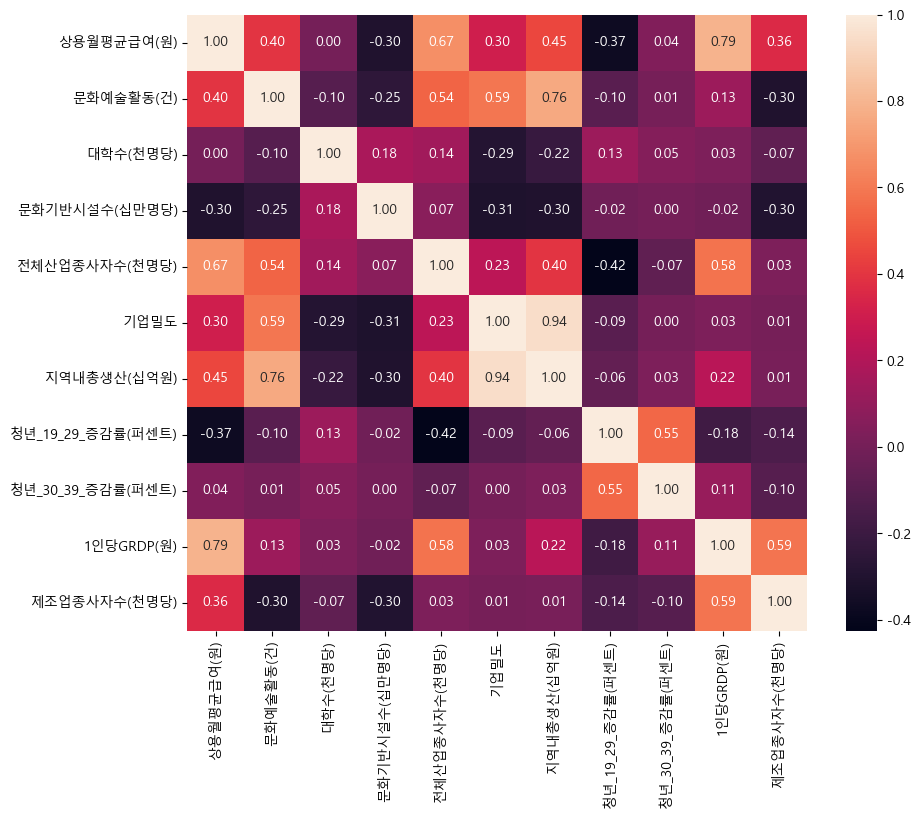

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".2f")
plt.show()

In [59]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    지정한 cols에 대해 VIF를 계산해서 DataFrame으로 반환.
    - NaN/inf는 자동 제거
    - 상수(constant) 컬럼은 자동 제거(있으면)
    """
    # 1) 필요한 컬럼만 추림
    X = df[cols].copy()

    # 2) inf -> NaN 처리 후 결측 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 3) 상수항(분산=0) 컬럼 제거 (VIF 계산 시 에러/무의미 방지)
    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)

    # 4) VIF 계산
    vif_df = pd.DataFrame({
        "var": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    return vif_df


In [60]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 독립 변수 리스트
x_cols = ['제조업종사자수', '상용월평균급여(원)', '문화예술활동(건)', '대학수(천명당)', 
          '문화기반시설수(십만명당)', '전체산업종사자수(천명당)',
          '기업밀도', '지역내총생산(십억원)']

#VIF 계산
vif = pd.DataFrame()
vif["var"] = x_cols
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values("VIF", ascending=False)

NameError: name 'X' is not defined